In [1]:
import os
import zarr
import numpy as np
import matplotlib.pyplot as plt
import trackpy as tp

import sys

sys.path.append(os.path.abspath(".."))
plt.style.use('../libs/my_style.mplstyle')

#mypass = '/mnt/ssd_data/Sasaki/MTSingleBeads'
mypass = '/Volumes/My Passport/Sasaki/MTsingleBeads'

folder = os.path.join(mypass, '20260122/exp002') 

path = os.path.join(folder, 'MTs_red.zarr')

MTs = zarr.open(path, mode='r')
# 1. データを読み込む（型変換せず、まずは元の型のまま）
raw_data = MTs[:] 

# 2. 結果格納用の配列を先に確保（uint8）
diff = np.zeros(raw_data[1:].shape, dtype=np.uint8)

# 3. 計算
# np.subtract の where 引数を使うことで、
# 「引いた結果が正の時だけ書き込む」という処理を1パスで実行可能
np.subtract(raw_data[1:], raw_data[:-1], out=diff, where=(raw_data[1:] > raw_data[:-1]))

array([[[ 0,  2, 12, ...,  1,  3,  0],
        [ 0,  3, 13, ...,  0,  8,  5],
        [ 0, 12, 16, ...,  0, 15, 14],
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [10,  2,  0, ...,  0,  0,  0],
        [25, 25, 15, ...,  0,  0,  0]],

       [[18, 15,  1, ...,  0,  0,  0],
        [26,  8,  0, ...,  0,  0,  0],
        [29,  3,  0, ...,  4,  1,  7],
        ...,
        [ 0, 11, 17, ...,  3,  0,  1],
        [ 0,  0,  7, ..., 18, 15, 19],
        [ 0,  0,  6, ..., 37, 40, 45]],

       [[ 0,  0,  0, ..., 19, 19, 15],
        [ 0,  0,  0, ...,  7,  5,  6],
        [ 0,  0,  0, ...,  0,  0,  0],
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0]],

       ...,

       [[13, 17, 11, ...,  0,  0,  0],
        [11, 13,  8, ...,  2,  0,  0],
        [11, 11, 11, ...,  9,  1,  0],
        ...,
        [ 3,  0,  0, ...,  2,  3,  3],
        [13,  1,  0, ...,  3,  2,  1],
        [27,  9,  0, ...,  0,  0

Text(0.5, 1.0, 'Histogram of intensity difference between frames')

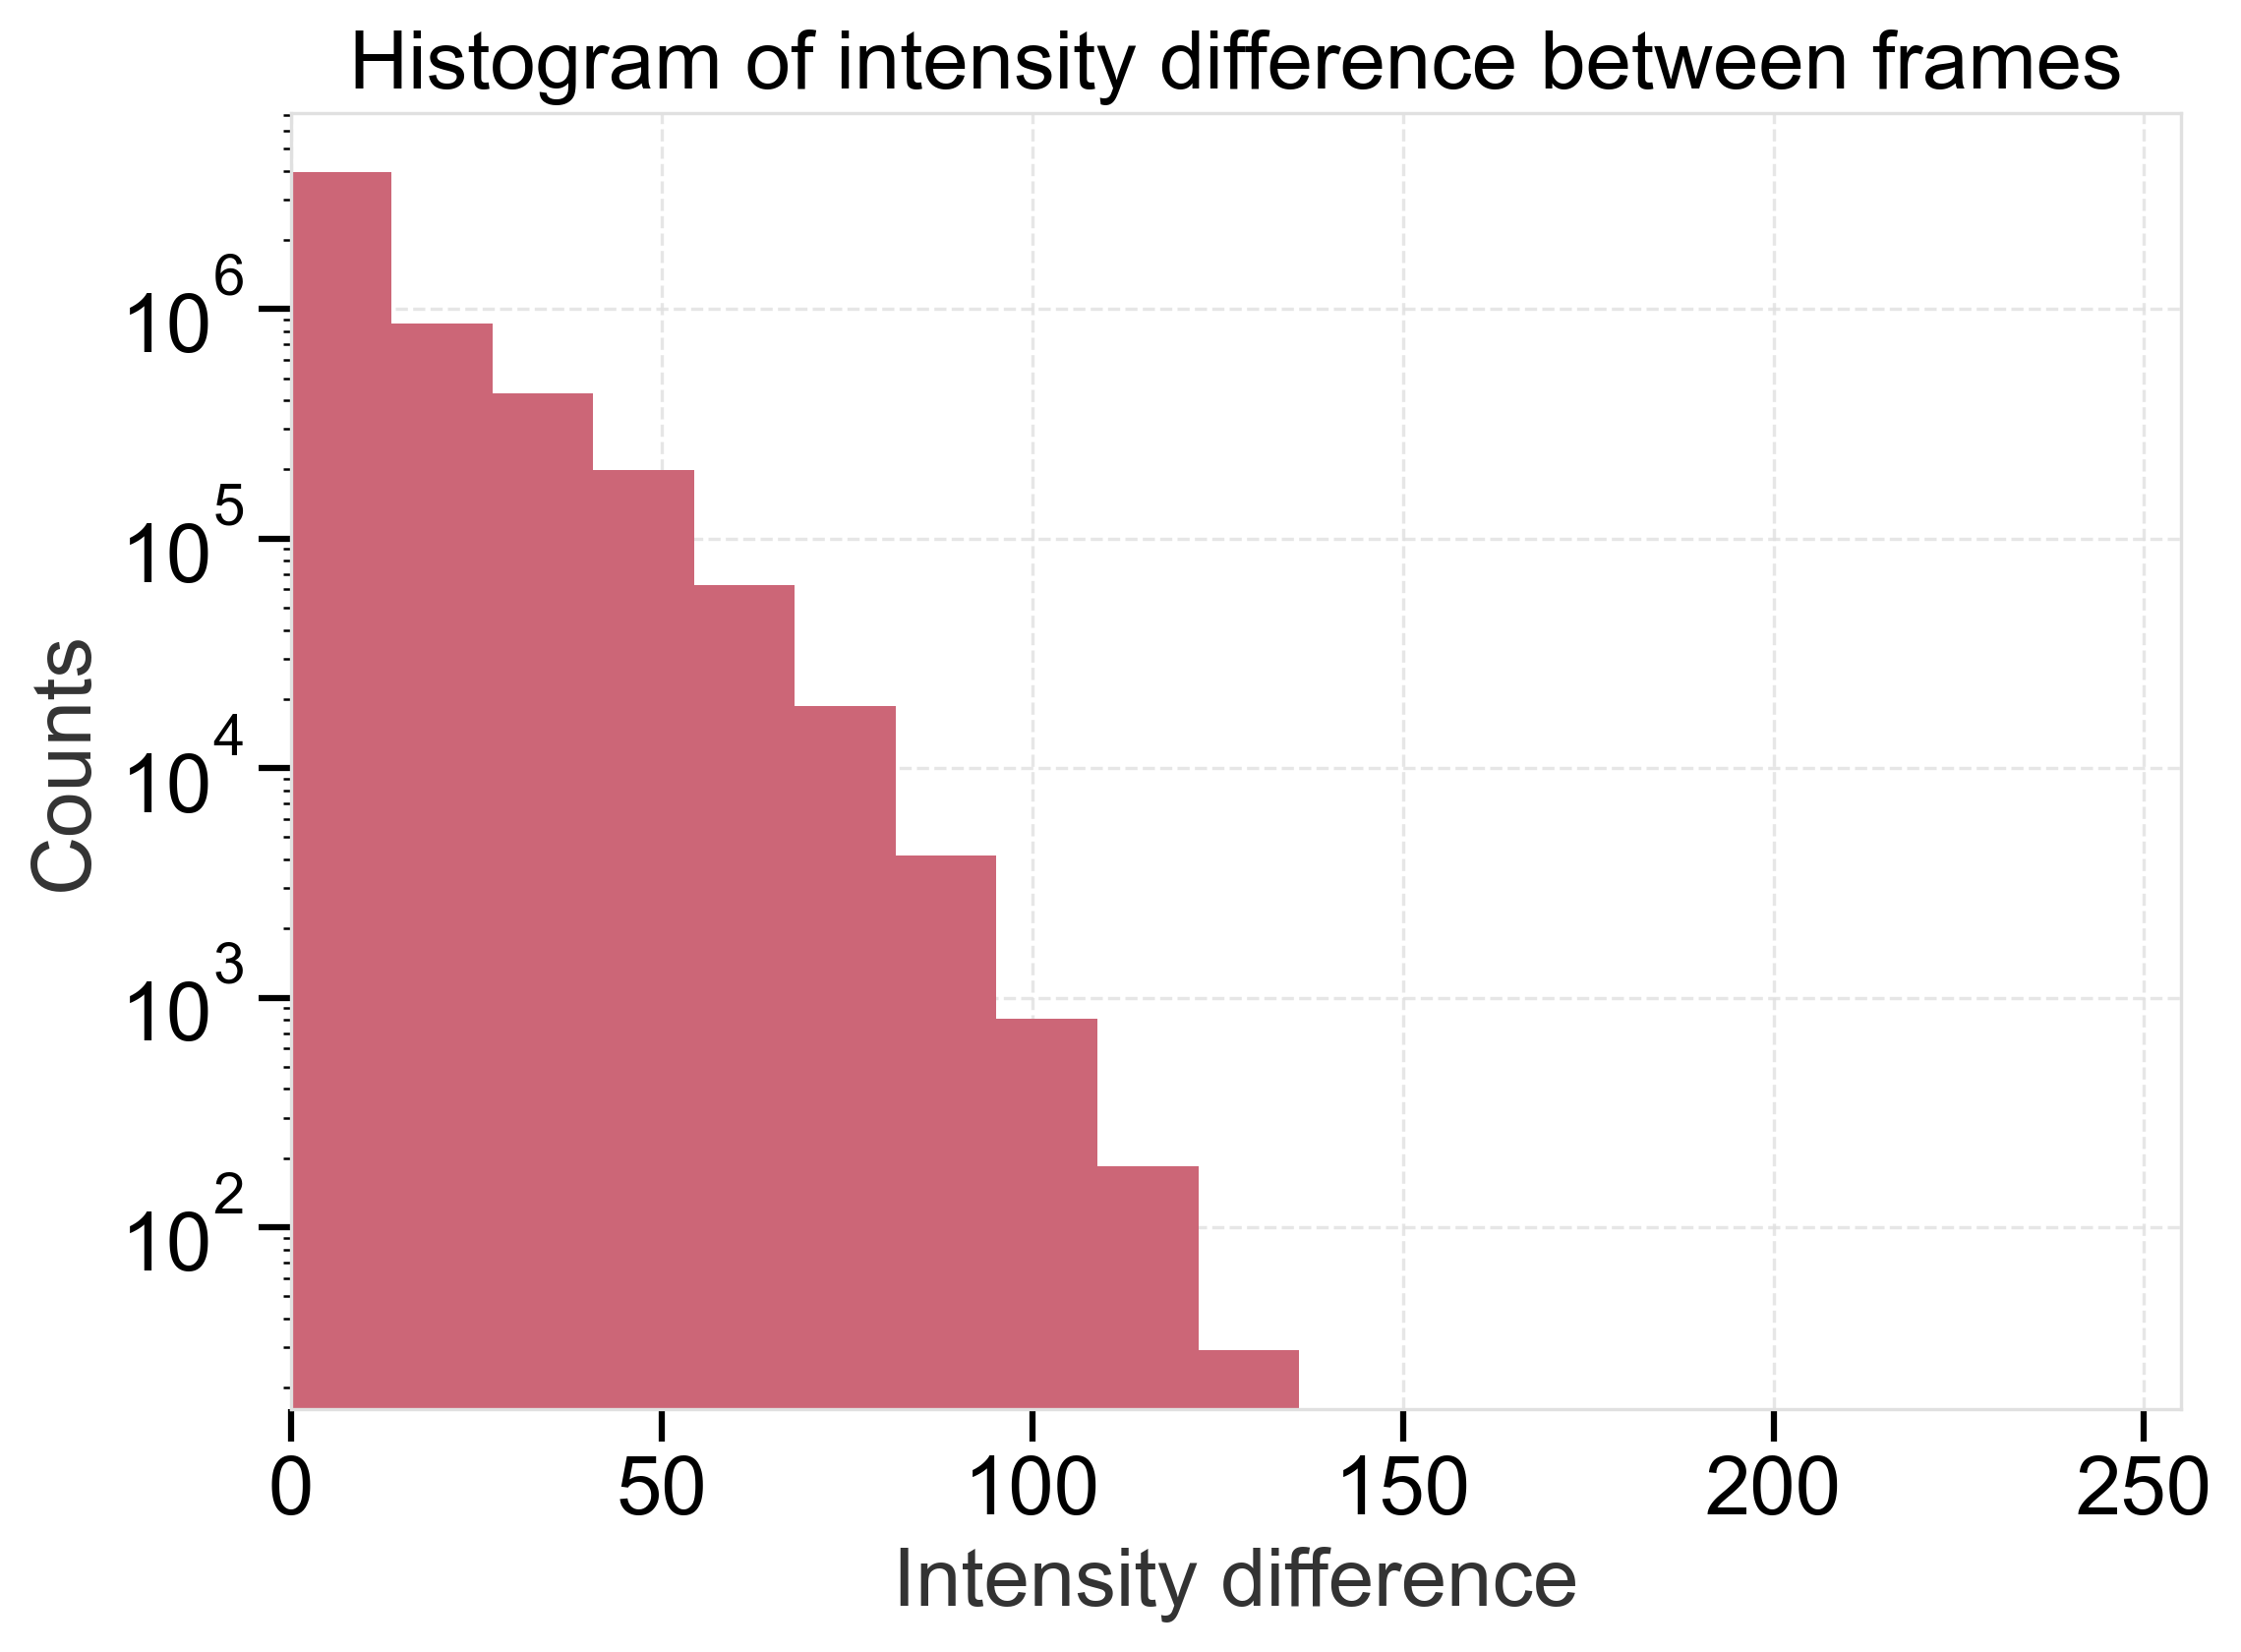

In [2]:
_=plt.hist(diff[0].reshape(-1))
plt.xlim(0, 255)
plt.yscale('log')
plt.xlabel('Intensity difference')
plt.ylabel('Counts')
plt.title('Histogram of intensity difference between frames')

In [4]:
velocity = 0.7  # um/s
scale = 0.11 # um/pixel
time_interval = 4.0  # s
growth_per_frame = int(velocity * time_interval / scale)  # pixels/frame

if growth_per_frame % 2 ==0:
    growth_per_frame = growth_per_frame + 1

print(f'Expected growth per frame: {growth_per_frame:.2f} pixels/frame')

Expected growth per frame: 25.00 pixels/frame


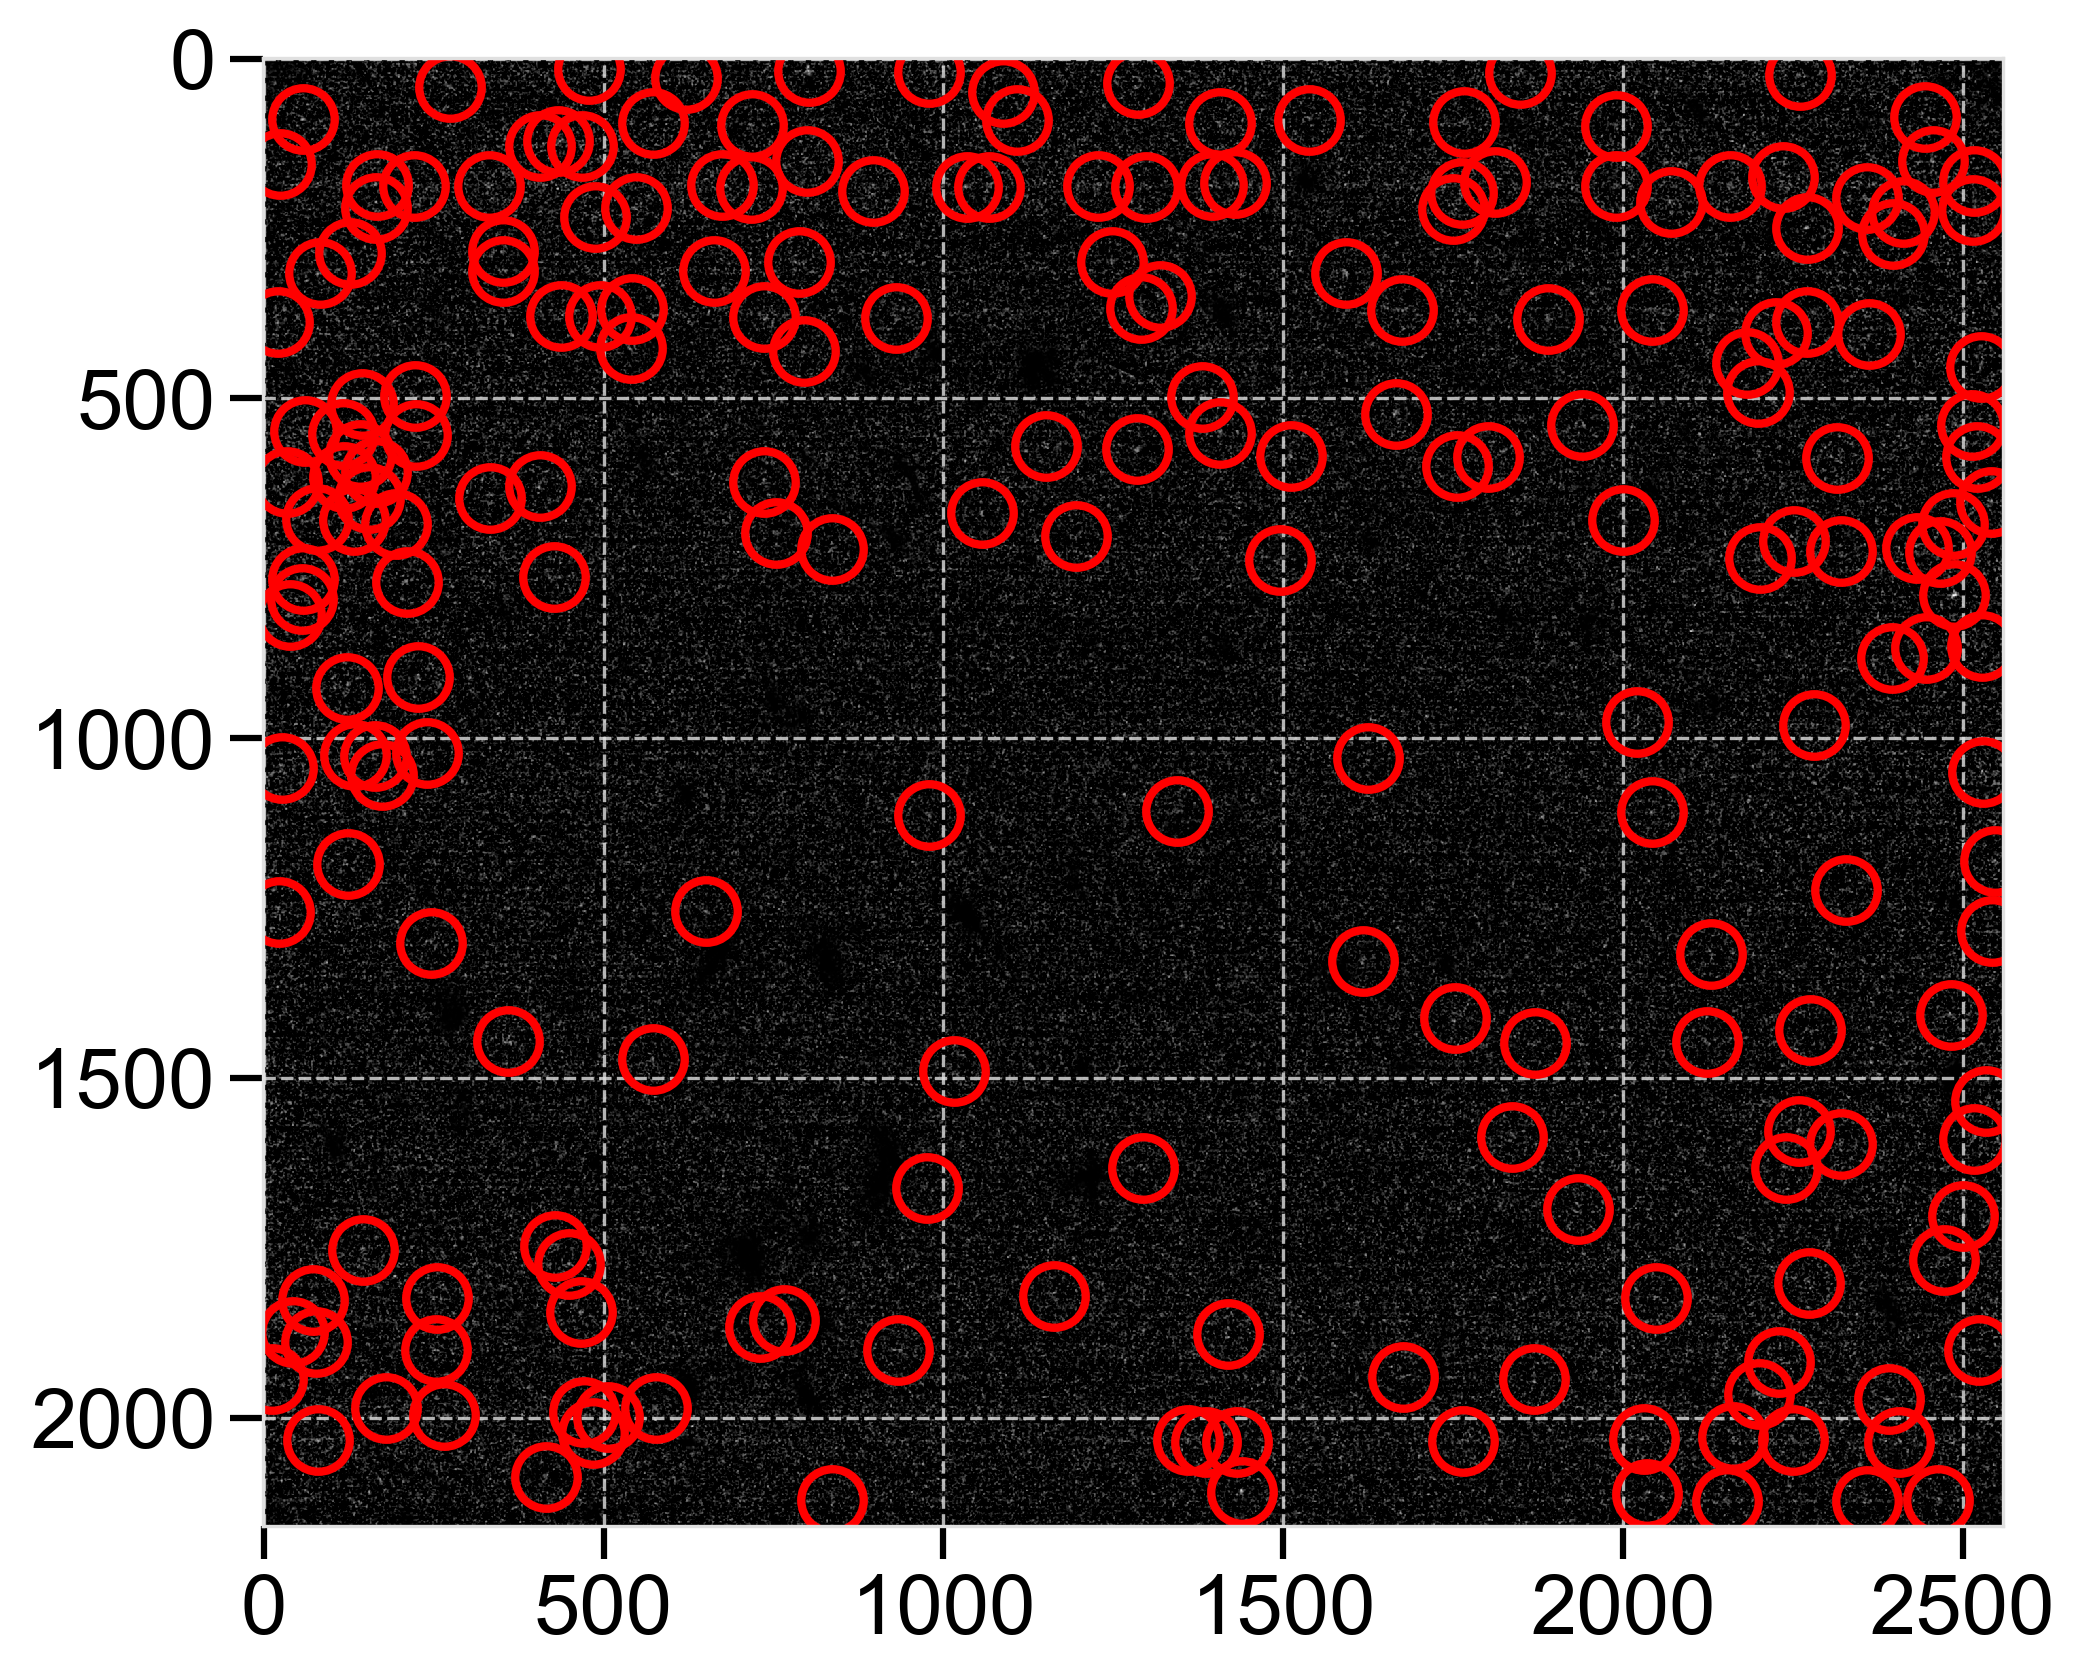

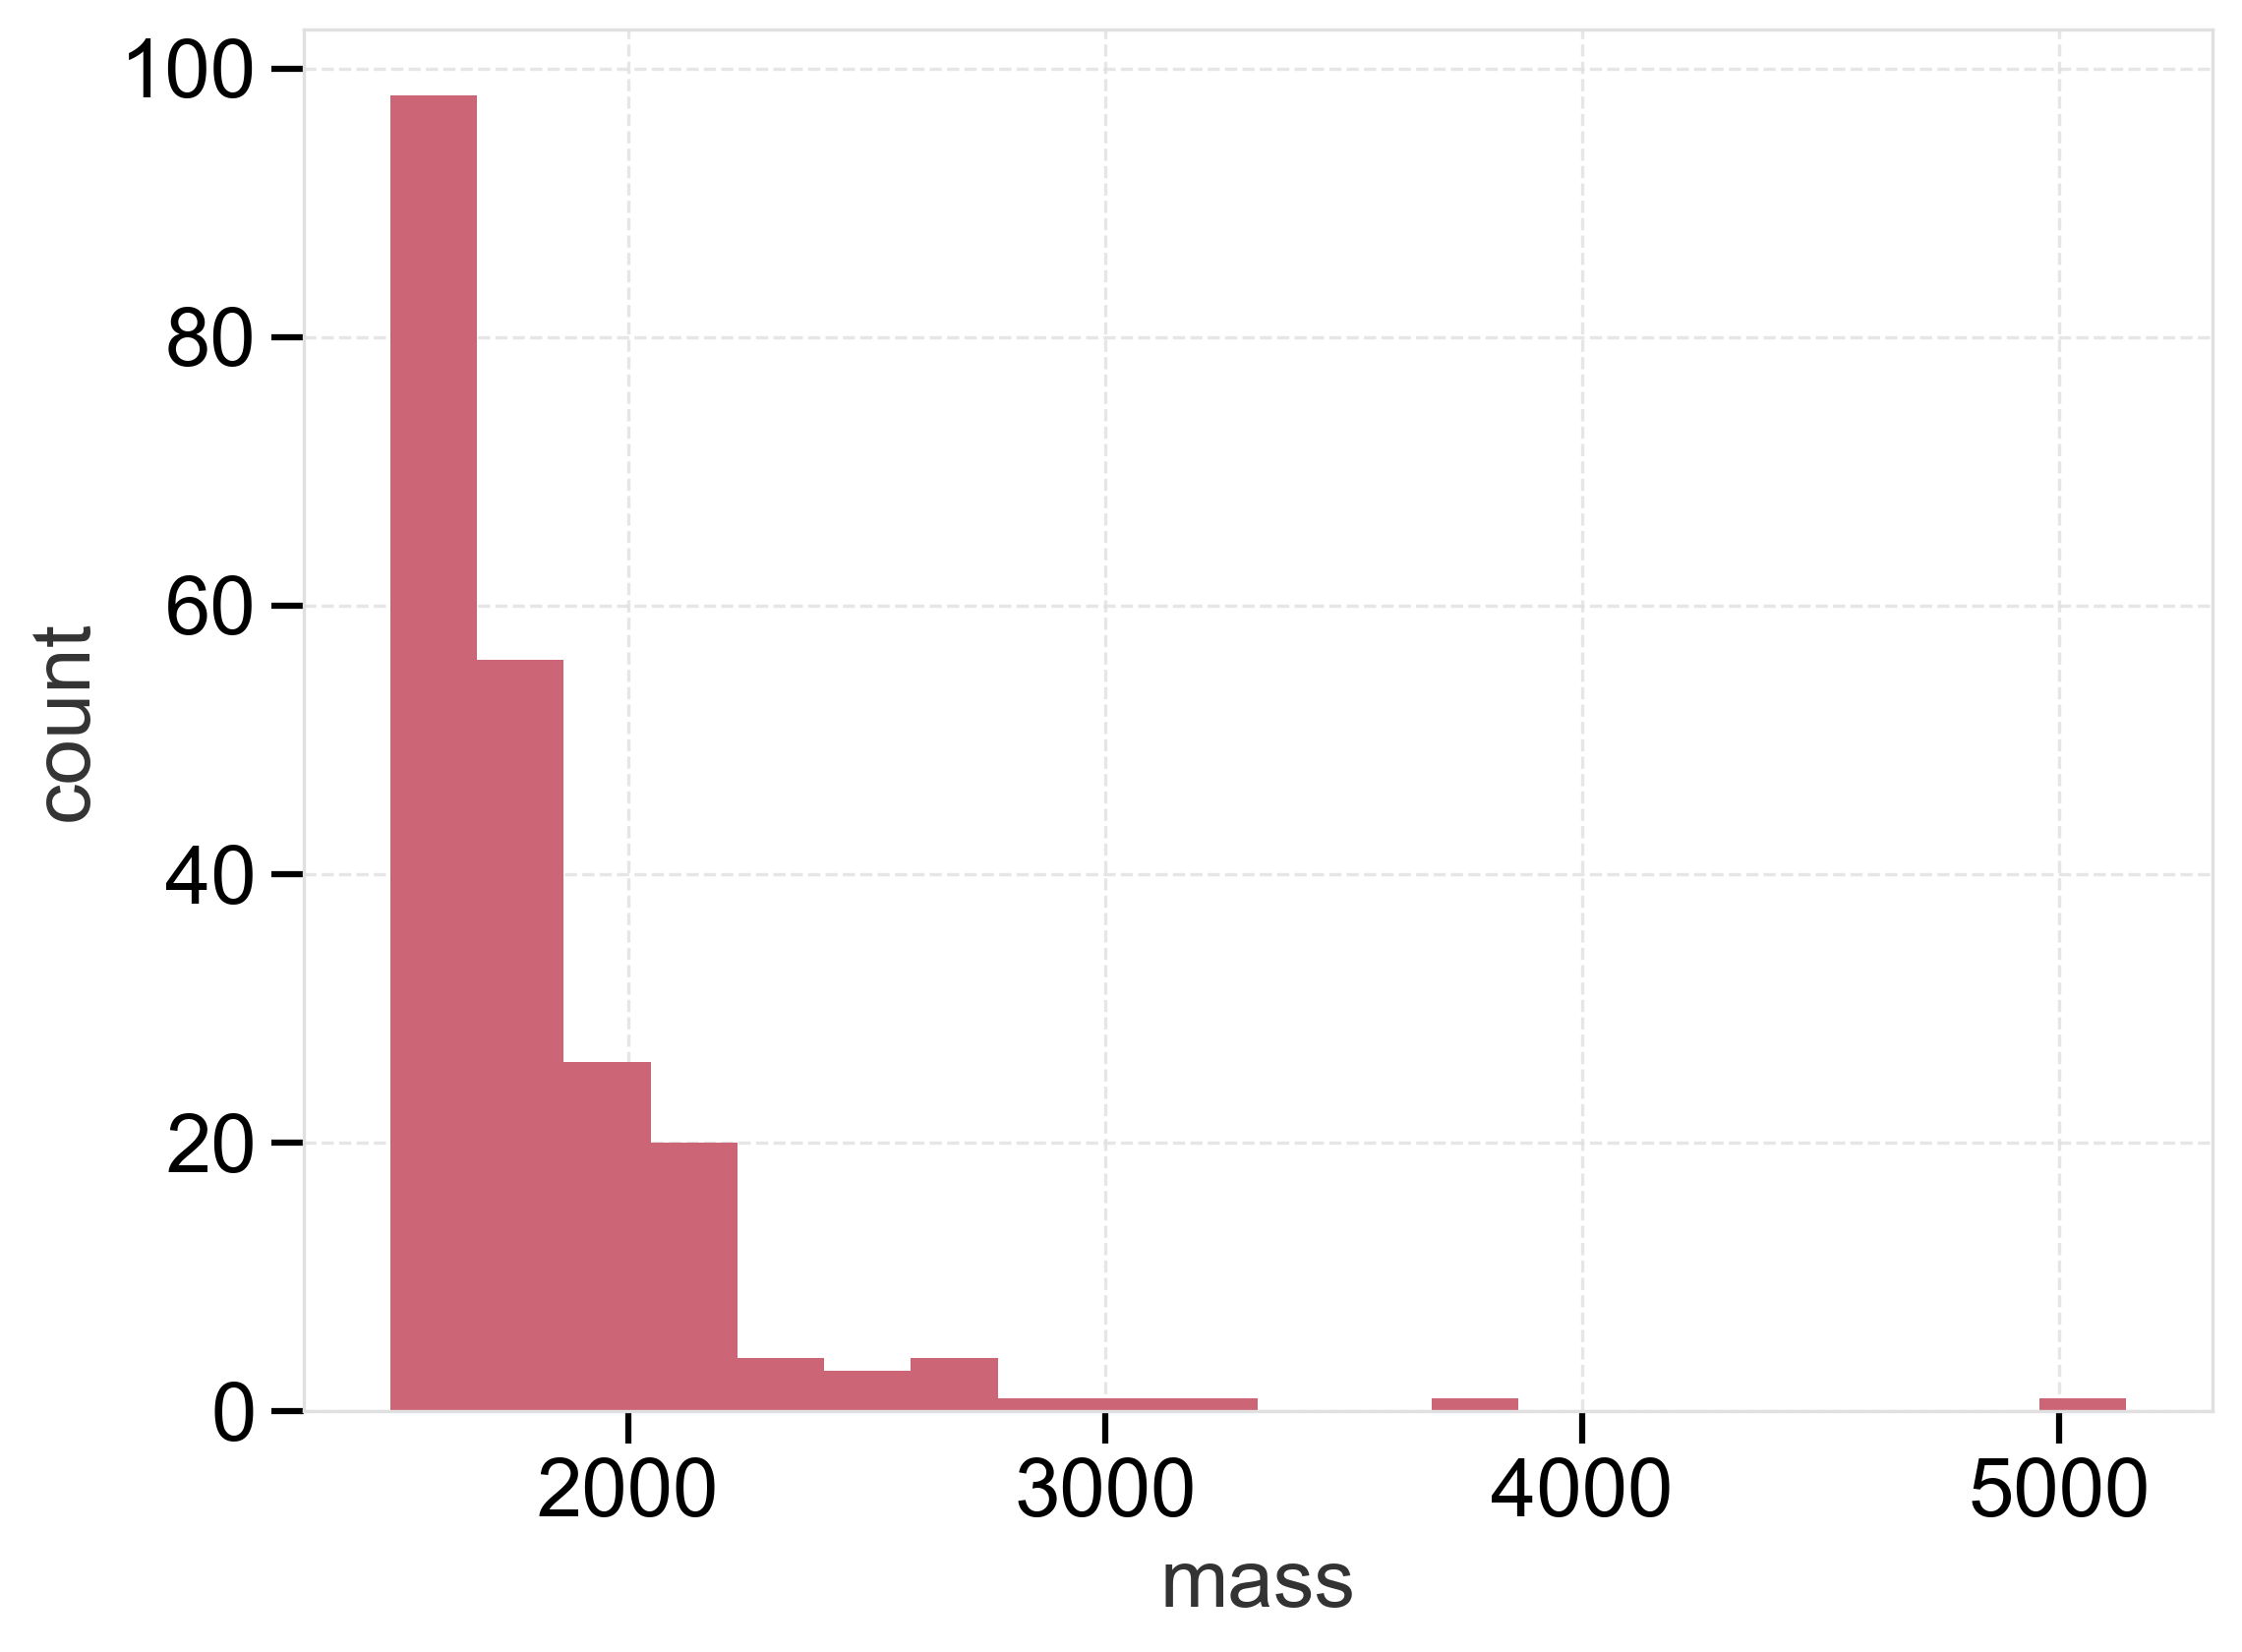

In [19]:
minmass = 1500
threshold = 10
noise_size = 2

t = 1000

f = tp.locate(diff[t], growth_per_frame, minmass = minmass, threshold=threshold , noise_size=noise_size)
tp.annotate(f, diff[t])

fig, ax = plt.subplots()
ax.hist(f['mass'], bins=20)
# Optionally, label the axes.
ax.set(xlabel='mass', ylabel='count');

#tp.subpx_bias(f)

In [20]:
f = tp.batch(diff, growth_per_frame, minmass = minmass, threshold=threshold, noise_size=noise_size)

Frame 1000: 216 features


In [21]:
tracks = tp.link(f, growth_per_frame)
t1 = tp.filter_stubs(tracks, 10)

Frame 1000: 216 trajectories present.


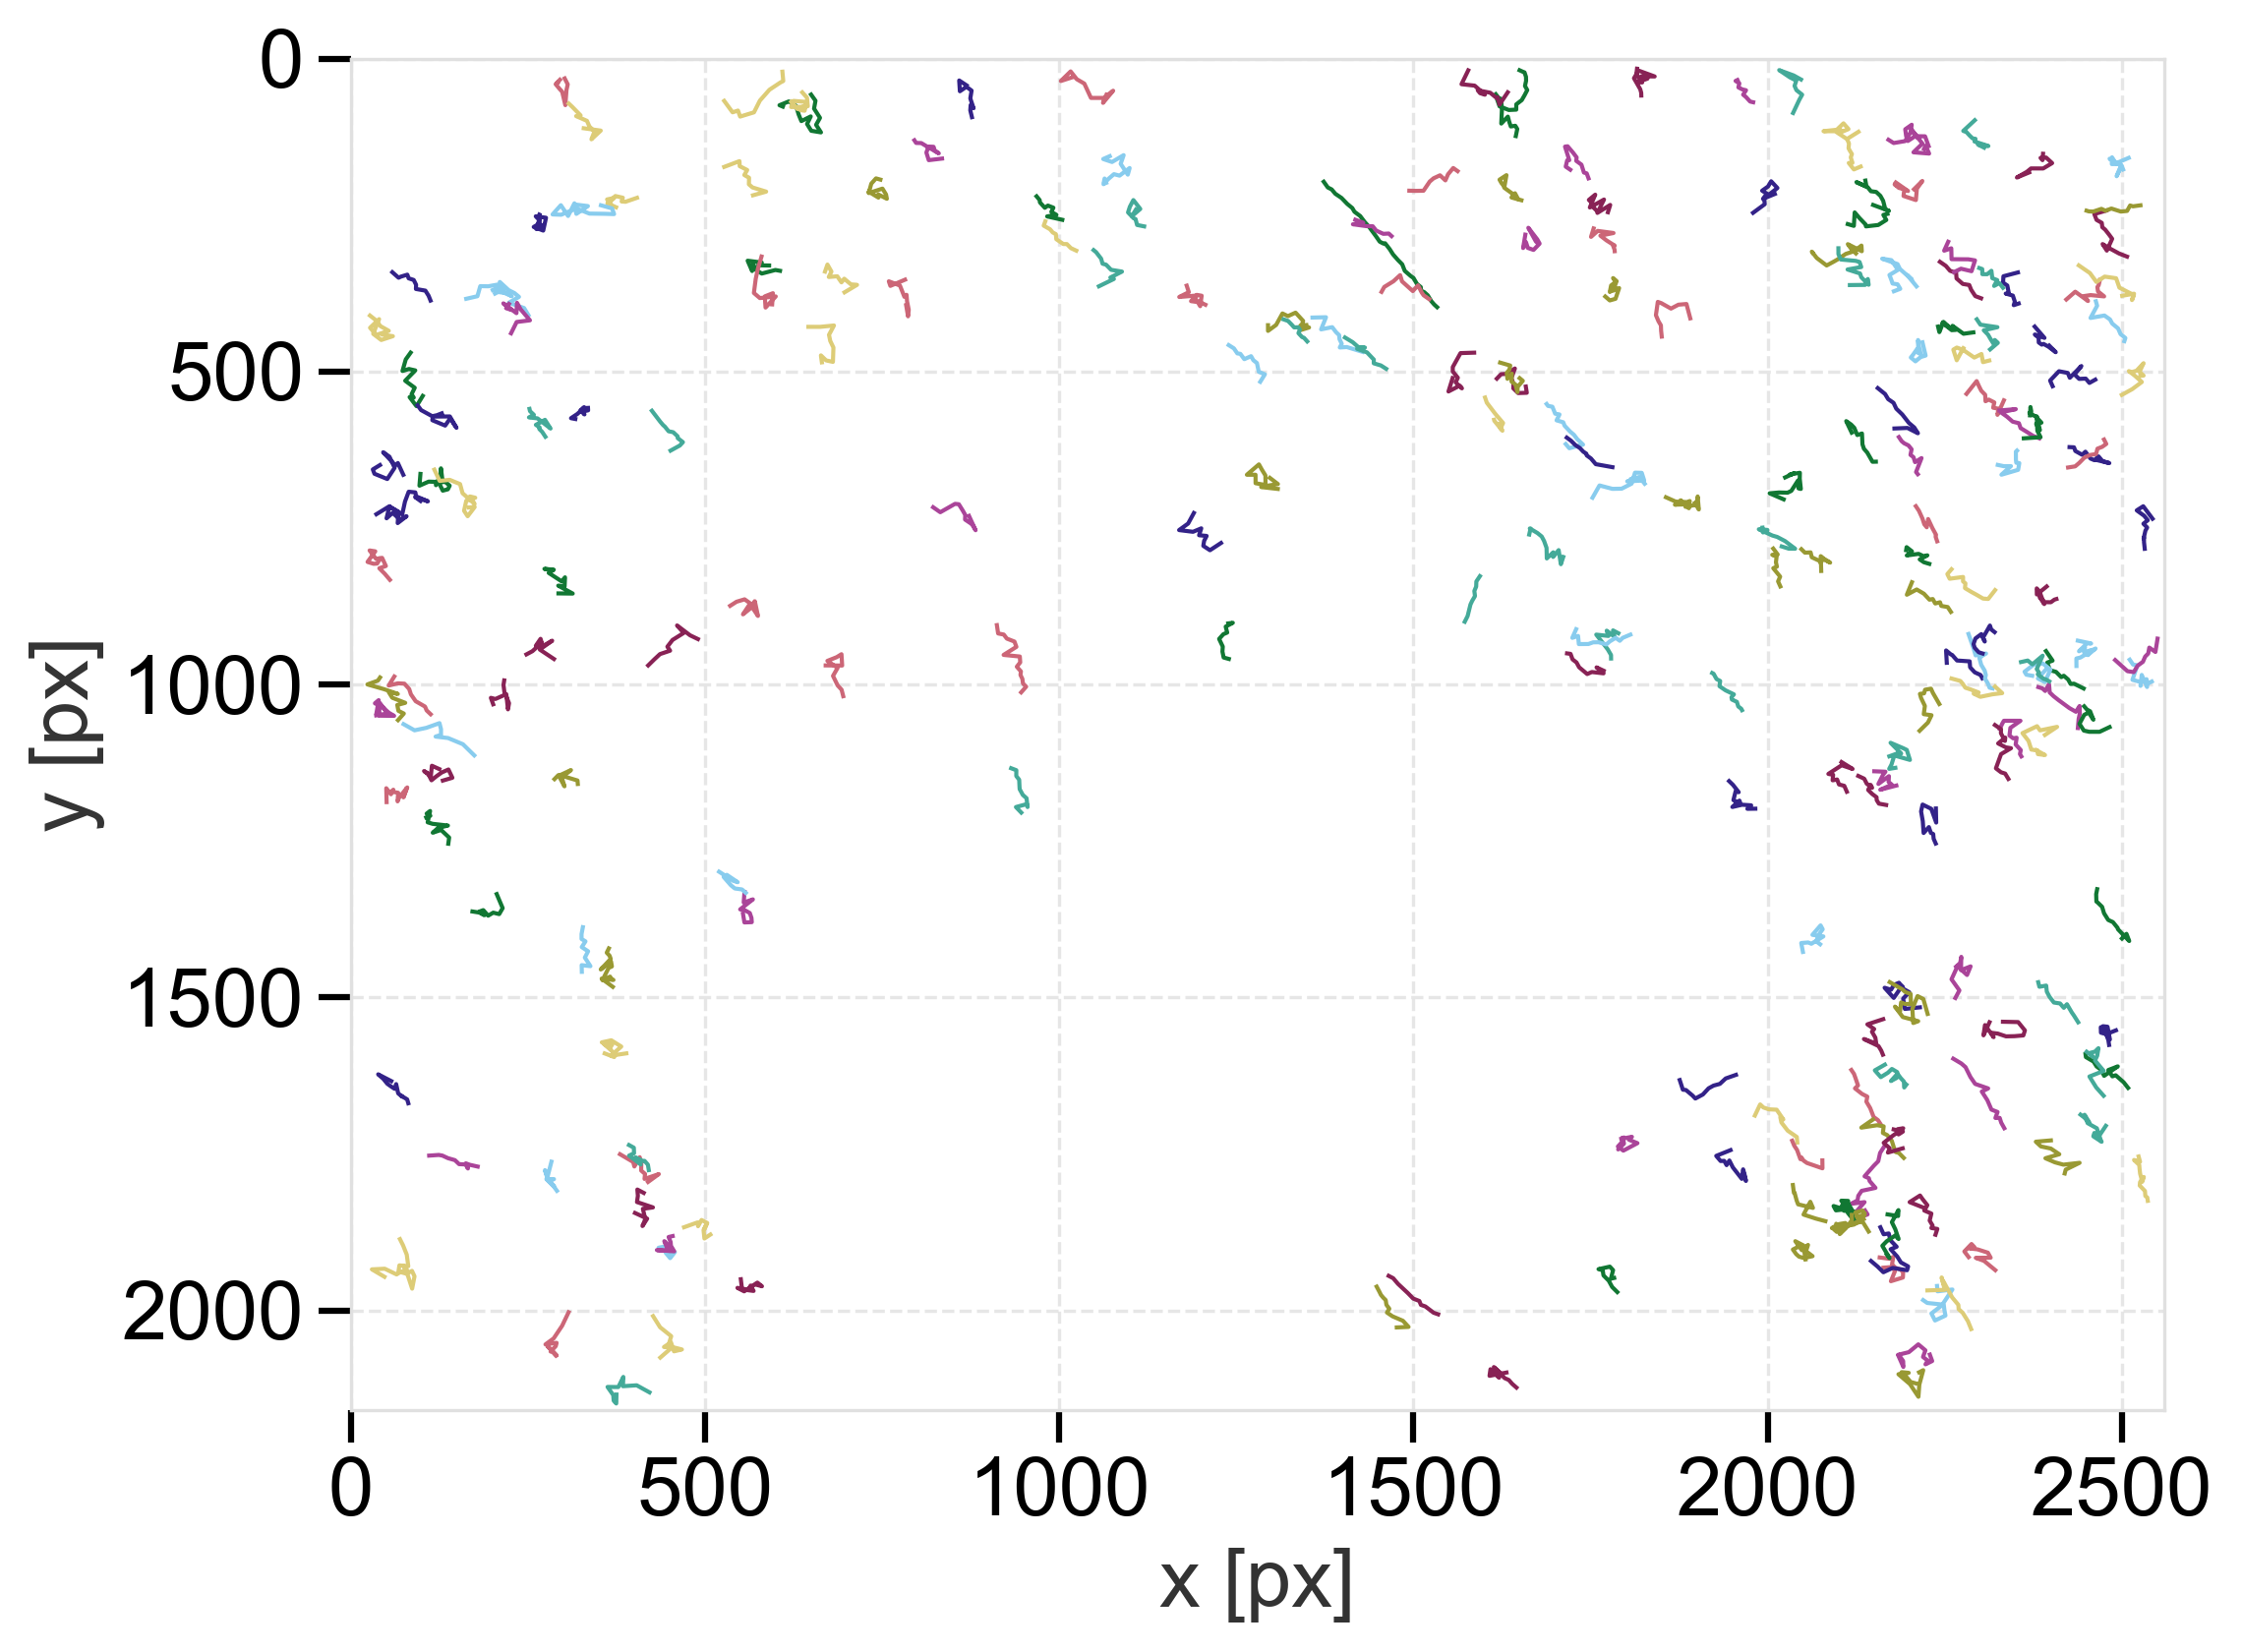

In [22]:
plt.figure()
plt.xlim((0, 2560))
plt.ylim((0, 2160))
tp.plot_traj(t1);

/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_52227/4147420093.py:6: RuntimeWarning: invalid value encountered in log10
  return k * x + np.log10(a)


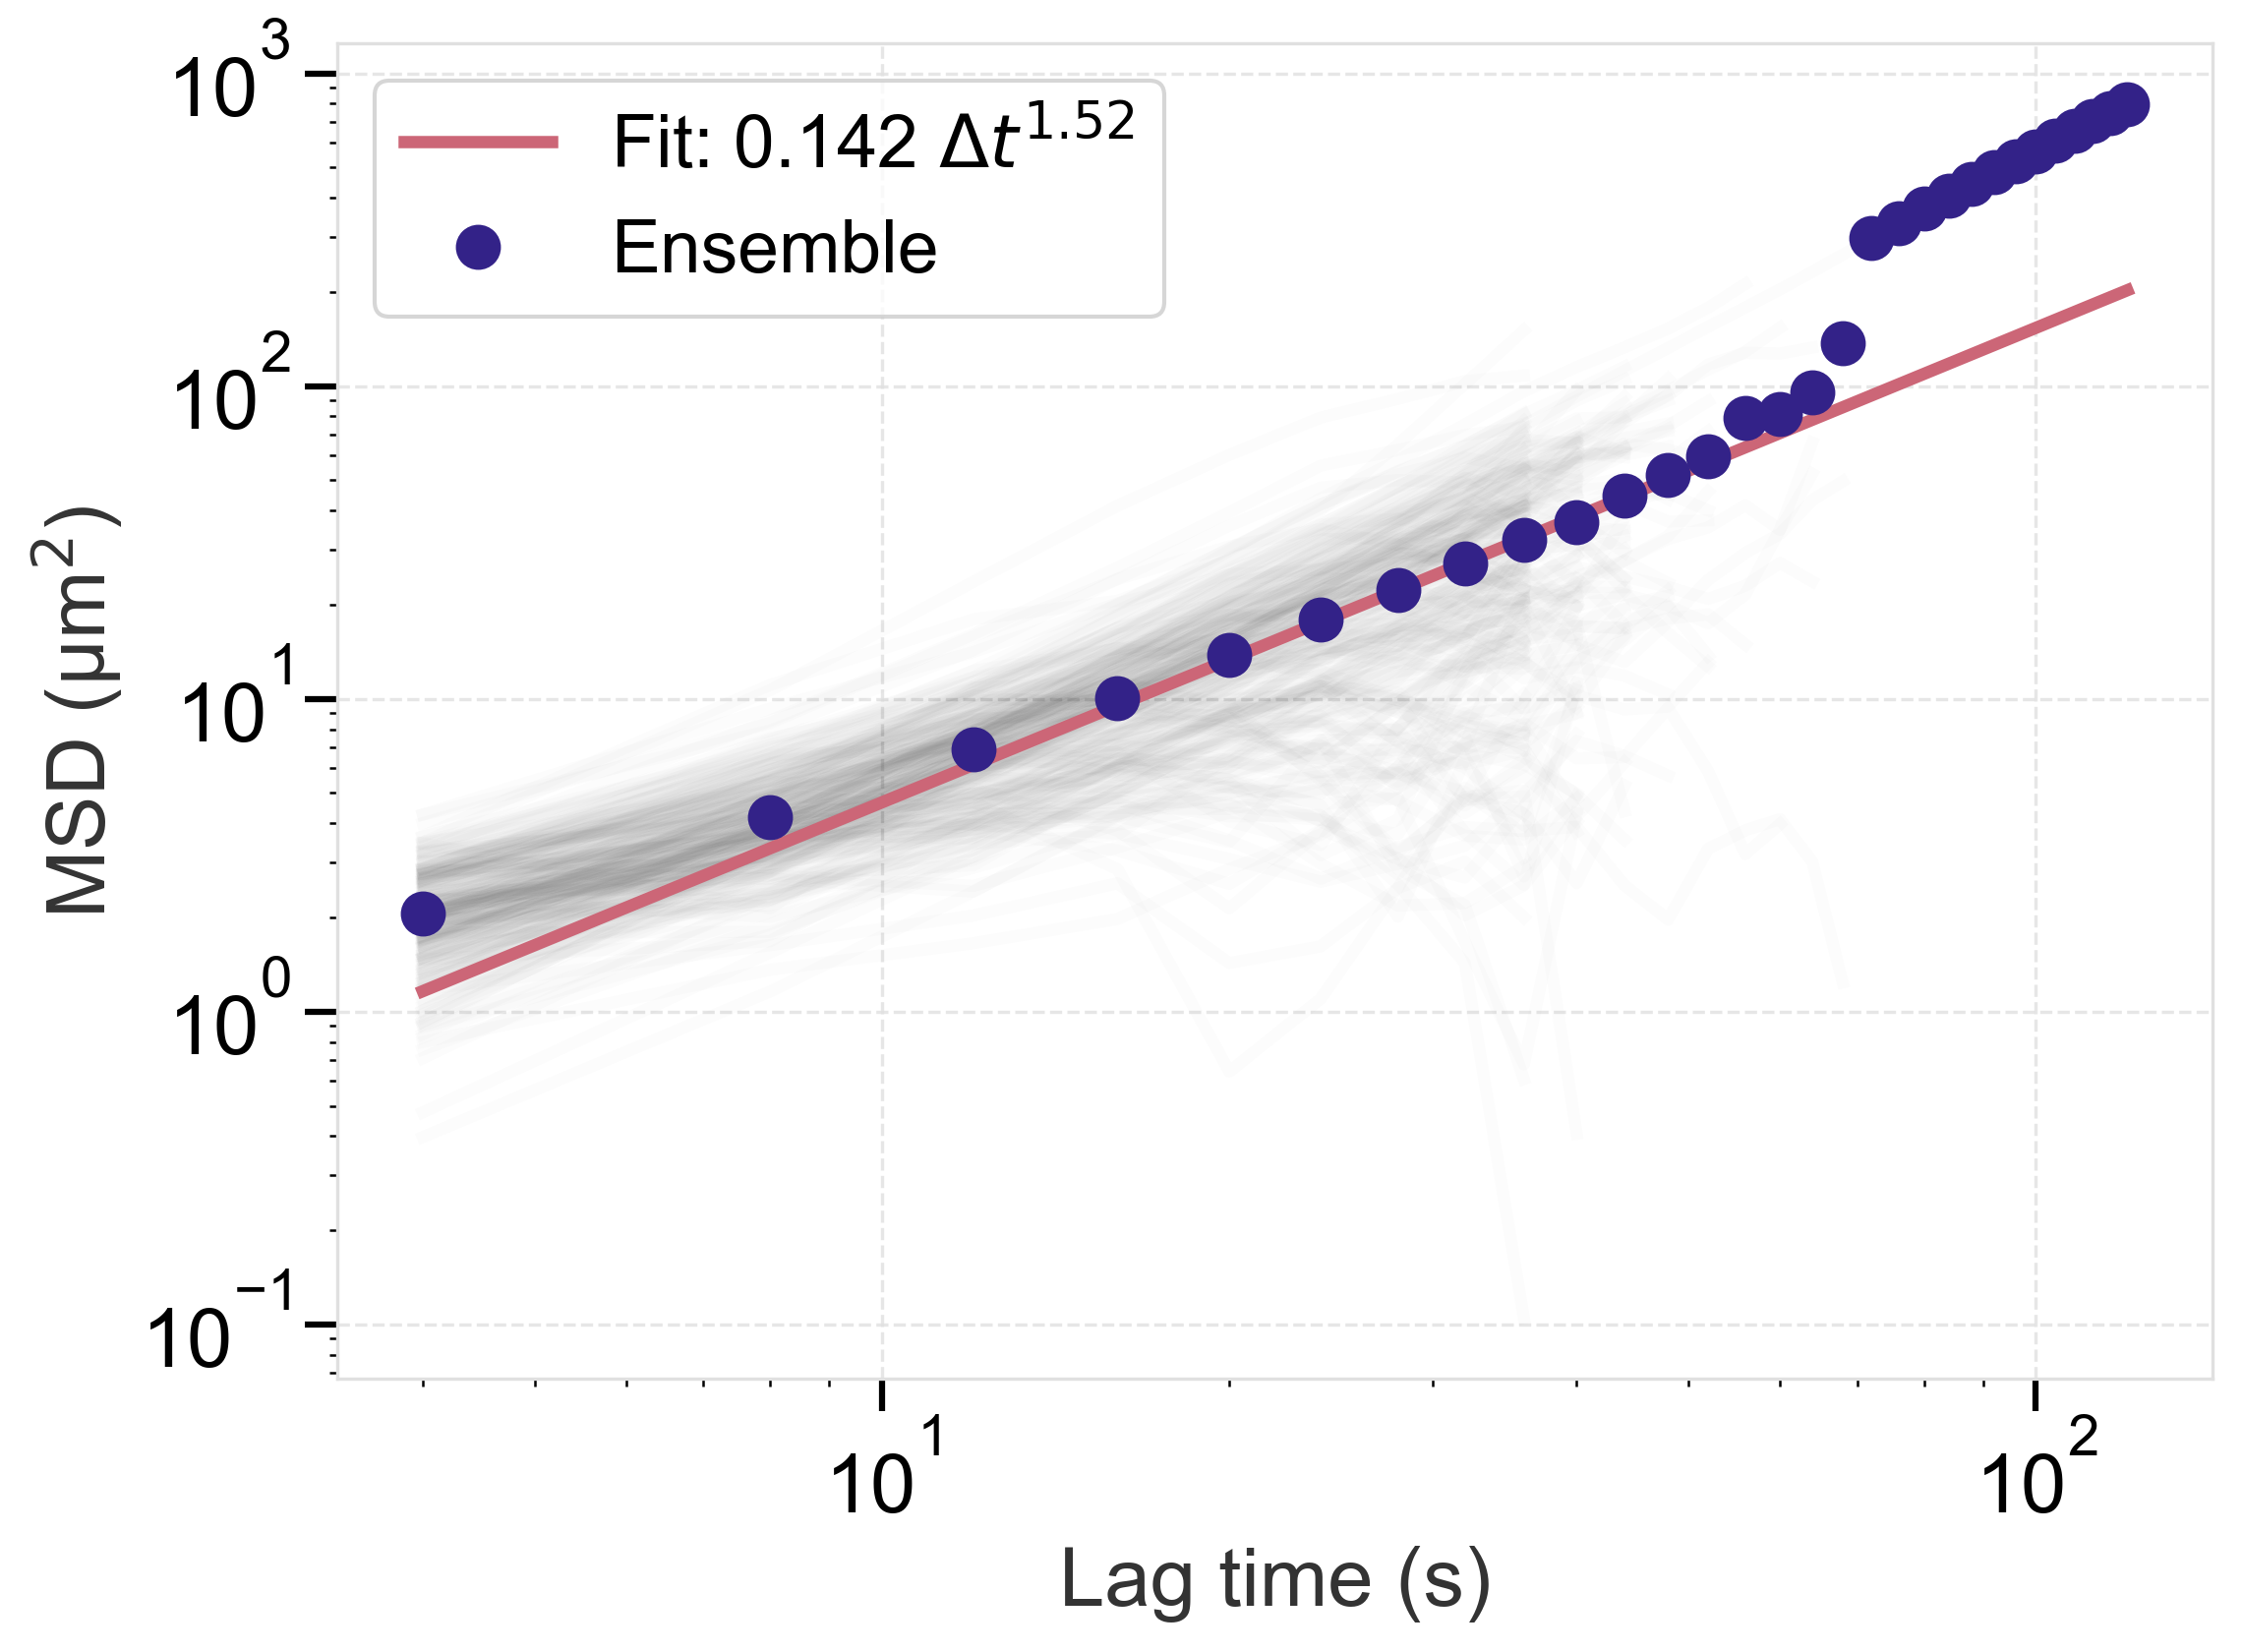

In [25]:
from scipy.optimize import curve_fit

def power_law(x, k, a):
    return a * np.abs(x) ** k
def ln_pl(x, k, a):
        return k * x + np.log10(a)

imsd = tp.imsd(t1, mpp=scale, fps=1/time_interval, max_lagtime=100)
emsd = tp.emsd(t1, mpp=scale, fps=1/time_interval, max_lagtime=100)

fig, ax = plt.subplots()
ax.plot(imsd.index, imsd, 'k-', alpha=0.01)

logx = np.log10(emsd.index.values)
logy = np.log10(emsd.values)

filter_x = np.where((logx > np.log10(20)) & (logx < np.log10(50)))

popt, pcov = curve_fit(ln_pl, logx[filter_x], logy[filter_x], p0=[0.1, 1.0])

ax.plot(emsd.index.values, power_law(emsd.index.values, *popt), label=f'Fit: {popt[1]:.3f} $\\Delta t^{{{popt[0]:.2f}}}$')

ax.plot(emsd.index, emsd, marker='o', linestyle = 'None', label='Ensemble')

ax.set_xlabel('Lag time (s)')
ax.set_ylabel('MSD (μm$^2$)')
ax.set(xscale='log', yscale='log')

ax.legend()

In [26]:
# Calculate velocity from fit (やばい値が出てたら精度が悪いので注意)
print(f"velocity from MSD: {np.sqrt(popt[1])} \u03bcm/s, velocity for track:{velocity} \u03bcm/s ")

velocity from MSD: 0.3767386446717309 μm/s, velocity for track:0.7 μm/s 


In [27]:
output = os.path.join(folder, 'MTtrack.csv') 
t1.to_csv(output, index=False)

In [28]:
output

'/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002/MTtrack.csv'